In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

mengimport library yang dibutuhkan seperti:

* pandas, untuk manipulasi data
* numpy, untuk kalkulasi matematika
* matplotlib.pyplot, untuk visualisasi
* train_test_split, untuk membagi data
* LinearRegression, untuk membangun model linear regresi
* metrics, untuk mengukur tingkat akurasi



In [77]:
data = {
    'durasi_hari': [3, 5, 7, 10, 14],
    'pengeluaran': [450, 700, 950, 1300, 1800]
}

df = pd.DataFrame(data)
print(df)

   durasi_hari  pengeluaran
0            3          450
1            5          700
2            7          950
3           10         1300
4           14         1800


Mendefinisikan nilai dari data yang akan digunakan dan mengubahkan menjadi format yang terstruktur yaitu Pandas DataFrame (df).

In [78]:
X = df[['durasi_hari']]
y = df['pengeluaran']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

proses pemisahan data menjadi 2, yaitu data training dan data testing dimana 80% data digunakan untuk training model dan 20% sisanya disisihkan untuk testing.

In [80]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [81]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): 85.38461538461524
Koefisien (b): 122.30769230769232


Proses pembelajaran dimulai, dimana sistem mencari hubungan antar variable pada data training, lalu menghitung persamaan garis linear terbaik.

Intercept (a): Titik awal pada sumbu Y. Dalam konteks perjalanan, ini mewakili biaya tetap (fixed cost) yang harus dikeluarkan bahkan sebelum hari pertama dimulai, seperti tiket pesawat atau biaya visa.

Koefisien (b): Kemiringan garis (slope). Ini mewakili tarif harian. Untuk setiap penambahan 1 hari perjalanan, biaya akan naik tepat sebesar angka ini.

In [82]:
y_pred = model.predict(X_test)

print("Data Testing")
print(X_test)
print("Pengeluaran Asli:", y_test.values)
print("Pengeluaran Prediksi:", y_pred)

Data Testing
   durasi_hari
1            5
Pengeluaran Asli: [700]
Pengeluaran Prediksi: [696.92307692]


`model.predict(X_test)`: memasukkan data hari pengujian (testing) yang disembunyikan ke dalam model, lalu menyuruh model menebak berapa pengeluarannya.

In [83]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 3.0769230769230944
MSE: 9.467455621301882
RMSE: 3.0769230769230944


Metrik Error (MAE, MSE, RMSE): Bagian ini menghitung seberapa jauh tebakan model (y_pred) menyimpang dari data asli yang disembunyikan (y_test). Semakin kecil angkanya, semakin akurat modelnya.

In [84]:
# Replace line 37 with this:
prediksi = model.predict(pd.DataFrame({'durasi_hari': [7]}))
print("Prediksi pengeluaran untuk trip 7 hari:", round(prediksi[0], 2))

Prediksi pengeluaran untuk trip 7 hari: 941.54


`model.predict([[7]])`: Menghasilkan prediksi pengeluaran baru untuk durasi trip 7 hari, di luar kumpulan data asli.

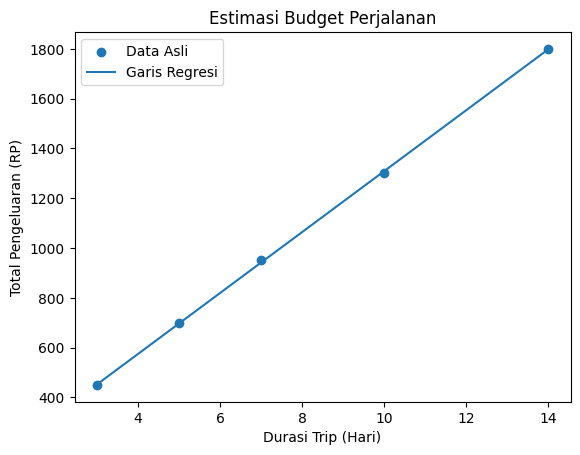

In [85]:
plt.scatter(X, y, label="Data Asli")
plt.plot(X, model.predict(X), label="Garis Regresi")
plt.xlabel("Durasi Trip (Hari)")
plt.ylabel("Total Pengeluaran (RP)")
plt.title("Estimasi Budget Perjalanan")
plt.legend()
plt.show()

`plt.scatter()`: Menggambar 5 titik data awal sebagai titik-titik (dot) pada grafik.

`plt.plot()`: Ini menggambar garis lurus regresi linear itu sendiri. Perintah ini meminta model memprediksi biaya untuk semua hari yang ada di variabel X, lalu menghubungkan titik-titik prediksi tersebut menjadi satu garis lurus.

`plt.show()`: Merender dan menampilkan grafik final ke layar.